# Annotation and Tile-Level Tumor Visualization

Using the Camelyon16 annotation XML files, this notebook visualizes tumor regions on the 20x tile grid in three ways:
1. **WSI thumbnail with tumor contours**
2. **Tile-grid view**: crop around each tumor region and label tiles as tumor or normal
3. **Embedding projection**: t-SNE or UMAP colored by tumor vs normal

Tunable parameters:
- `SLIDE_ID`: slide name, for example `"tumor_001"`
- `TUMOR_THRESH`: minimum tumor area ratio for labeling a tile as tumor, default `0.20`
- `CONTEXT_PAD`: number of extra tile rows and columns to include around each tumor region, default `10`
- `EMBEDDING_KEY`: embedding version to use, either `"embeddings_20x_s"` or `"embeddings_20x_i"`

In [ ]:
import numpy as np
import h5py
import openslide
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
from pathlib import Path
import xml.etree.ElementTree as ET
from shapely.geometry import Polygon, box
from shapely.ops import unary_union

print(f"openslide : {openslide.__version__}")

openslide : 1.4.1


In [ ]:
# User-facing parameters
SLIDE_ID      = "tumor_014"
TUMOR_THRESH  = 0.30     # Label a tile as tumor if its tumor-area ratio reaches this threshold
CONTEXT_PAD   = 10       # Extra tile rows and columns to show around each tumor region
EMBEDDING_KEY = "embeddings_20x_i"   # Either "embeddings_20x_s" or "embeddings_20x_i"
CLUSTER_GAP   = 30       # Tile-distance threshold used to split nearby tumor regions into clusters

# Paths
SLIDE_DIR  = Path("data/camelyon16/training/tumor")
ANNOT_DIR  = Path("data/camelyon16/annotations")
H5_DIR     = Path("tile_database")

slide_path = SLIDE_DIR / f"{SLIDE_ID}.tif"
xml_path   = ANNOT_DIR / f"{SLIDE_ID}.xml"
h5_path    = H5_DIR    / f"{SLIDE_ID}.h5"

for p, label in [(slide_path, "slide"), (xml_path, "annotation"), (h5_path, "h5")]:
    assert p.exists(), f"{label} not found: {p}"
    print(f"  {label:10s} : {p}")

  slide      : data\camelyon16\training\tumor\tumor_014.tif
  annotation : data\camelyon16\annotations\tumor_014.xml
  h5         : tile_database\tumor_014.h5


## Core Functions

- `parse_annotations_xml`: parse an ASAP-format XML file and return a list of Shapely polygons in level-0 coordinates
- `compute_tile_tumor_labels`: compute the tumor-area overlap ratio for each tile
- `cluster_tumor_regions`: group neighboring tumor tiles into separate visualization regions

In [ ]:
def parse_annotations_xml(xml_path):
    """
    Parse an ASAP-format annotation XML file and return a list of Shapely polygons.
    Coordinates are absolute pixel positions at level 0.
    MultiPolygons are split into individual polygons.
    """
    tree = ET.parse(str(xml_path))
    root = tree.getroot()
    polygons = []
    for ann in root.iter('Annotation'):
        coords_elems = ann.findall('Coordinates/Coordinate')
        if len(coords_elems) < 3:
            continue
        pts = [(float(c.attrib['X']), float(c.attrib['Y'])) for c in coords_elems]
        poly = Polygon(pts)
        if poly.is_valid and not poly.is_empty:
            polygons.append(poly)
        else:
            # Try to repair invalid polygons. buffer(0) can return a MultiPolygon.
            poly = poly.buffer(0)
            if not poly.is_empty:
                if poly.geom_type == 'MultiPolygon':
                    polygons.extend([g for g in poly.geoms if not g.is_empty])
                else:
                    polygons.append(poly)
    return polygons


def compute_tile_tumor_labels(coords, tile_size_l0, tumor_polygons):
    """
    Compute the overlap ratio between each tile and the tumor polygons.
    A bounding-box pre-filter is used so exact intersections are only computed
    for tiles that could plausibly overlap the tumor region.


    Args:
        coords: (N, 2) int32 array of level-0 (x, y) positions
        tile_size_l0: tile width in level-0 pixels
        tumor_polygons: list of Shapely polygons

    Returns:
        tumor_ratios: (N,) float32 array with the tumor-area ratio of each tile
    """
    tumor_union = unary_union(tumor_polygons)
    N = len(coords)
    tumor_ratios = np.zeros(N, dtype=np.float32)
    tile_area = float(tile_size_l0 * tile_size_l0)

    # Pre-filter tiles using the bounding box of the merged tumor region.
    tb = tumor_union.bounds  # (minx, miny, maxx, maxy)

    xs = coords[:, 0].astype(np.float64)
    ys = coords[:, 1].astype(np.float64)
    candidate_mask = (
        (xs + tile_size_l0 >= tb[0]) & (xs <= tb[2]) &
        (ys + tile_size_l0 >= tb[1]) & (ys <= tb[3])
    )
    candidate_idx = np.where(candidate_mask)[0]
    print(f"    bbox pre-filter: {len(candidate_idx)}/{N} candidates")

    for count, i in enumerate(candidate_idx):
        x, y = int(coords[i, 0]), int(coords[i, 1])
        tile_box = box(x, y, x + tile_size_l0, y + tile_size_l0)
        inter = tumor_union.intersection(tile_box)
        if not inter.is_empty:
            tumor_ratios[i] = inter.area / tile_area
        if (count + 1) % 500 == 0:
            print(f"    [{count+1}/{len(candidate_idx)}]")

    return tumor_ratios


def cluster_tumor_regions(tumor_mask_grid, context_pad, cluster_gap):
    """
    Group tumor tiles in the 2D tile grid into separate regions using connected
    components after dilation, and return a list of `(row_slice, col_slice)` pairs.


    Args:
        tumor_mask_grid: (n_rows, n_cols) bool array
        context_pad: extra tile padding added around each region
        cluster_gap: dilation size used to merge nearby tumor components
    """
    n_rows, n_cols = tumor_mask_grid.shape

    # Dilate first so nearby tumor islands are treated as one region.
    kernel = np.ones((cluster_gap, cluster_gap), np.uint8)
    dilated = cv2.dilate(tumor_mask_grid.astype(np.uint8), kernel, iterations=1)
    n_labels, labels = cv2.connectedComponents(dilated)

    regions = []
    for label_id in range(1, n_labels):
        # Go back to the original mask to get a tighter region boundary.
        mask_in_cluster = tumor_mask_grid & (labels == label_id)
        if not mask_in_cluster.any():
            continue
        t_ys, t_xs = np.where(mask_in_cluster)
        r_min = max(0, t_ys.min() - context_pad)
        r_max = min(n_rows, t_ys.max() + context_pad + 1)
        c_min = max(0, t_xs.min() - context_pad)
        c_max = min(n_cols, t_xs.max() + context_pad + 1)
        regions.append((slice(r_min, r_max), slice(c_min, c_max)))

    return regions


print("Core functions defined.")

Core functions defined.


## Load the Data

Read tile coordinates, tissue mask, and embeddings from HDF5, then parse the annotation XML.

In [ ]:
# 1) Read data from HDF5
with h5py.File(h5_path, 'r') as f:
    coords      = f['coords'][:]            # (N, 2) int32, level-0 (x, y)
    tissue_mask = f['tissue_mask'][:]       # (N,) bool
    thumbnail   = f['thumbnail'][:]         # (H, W, 3) uint8
    embeddings  = f[EMBEDDING_KEY][:]       # (N, D) float32
    tile_size   = int(f.attrs['tile_size']) # 224
    level_20x   = int(f.attrs['level_20x'])
    slide_dims  = tuple(f.attrs['slide_dimensions'])  # (W, H) at level 0

N = len(coords)
print(f"Loaded {h5_path.name}:")
print(f"  N={N}, tile_size={tile_size}, level_20x={level_20x}")
print(f"  slide dims: {slide_dims}")
print(f"  tissue tiles: {tissue_mask.sum()}/{N}")
print(f"  embedding: {EMBEDDING_KEY} {embeddings.shape}")

# 2) Parse the annotation XML
tumor_polygons = parse_annotations_xml(xml_path)
print(f"  annotation polygons: {len(tumor_polygons)}")
for i, poly in enumerate(tumor_polygons):
    b = poly.bounds
    print(f"    [{i}] bbox x=[{b[0]:.0f}, {b[2]:.0f}], y=[{b[1]:.0f}, {b[3]:.0f}], "
          f"area={poly.area:.0f}")

# 3) Compute tile-level tumor ratios
# Infer the tile span at level 0 from adjacent x coordinates.
xs_unique = np.sort(np.unique(coords[:, 0]))
tile_size_l0 = int(xs_unique[1] - xs_unique[0]) if len(xs_unique) > 1 else tile_size
print(f"  tile_size at level-0: {tile_size_l0} px")

print("Computing tile-level tumor ratios ...")
tumor_ratios = compute_tile_tumor_labels(coords, tile_size_l0, tumor_polygons)
tumor_labels = tumor_ratios >= TUMOR_THRESH   # (N,) bool
n_tumor = int(tumor_labels.sum())
print(f"  tumor tiles (thresh>={TUMOR_THRESH:.0%}): {n_tumor}/{N}")

# 4) Recover the tile-grid shape
n_cols = len(xs_unique)
ys_unique = np.sort(np.unique(coords[:, 1]))
n_rows = len(ys_unique)
print(f"  grid: {n_cols} cols x {n_rows} rows")

Loaded tumor_014.h5:
  N=103986, tile_size=224, level_20x=1
  slide dims: (np.int64(97792), np.int64(214016))
  tissue tiles: 23720/103986
  embedding: embeddings_20x_i (103986, 512)
  annotation polygons: 13
    [0] bbox x=[23849, 29417], y=[66274, 69571], area=10439250
    [1] bbox x=[27704, 27938], y=[68190, 68453], area=44803
    [2] bbox x=[27851, 30193], y=[65023, 67116], area=2110031
    [3] bbox x=[38039, 48776], y=[68094, 77234], area=56895189
    [4] bbox x=[41947, 42124], y=[76998, 77151], area=14043
    [5] bbox x=[42252, 42504], y=[76698, 76919], area=41023
    [6] bbox x=[47751, 48072], y=[72831, 73446], area=87739
    [7] bbox x=[43742, 44310], y=[73401, 74079], area=260645
    [8] bbox x=[43696, 44788], y=[69634, 70318], area=428706
    [9] bbox x=[43830, 44385], y=[70255, 70660], area=112262
    [10] bbox x=[44886, 45349], y=[72816, 73332], area=122439
    [11] bbox x=[44822, 45588], y=[72290, 72653], area=87358
    [12] bbox x=[47254, 47876], y=[71296, 71727], area=18

## Figure 1: WSI Thumbnail with Tumor Contours

Draw the annotation polygons on the low-resolution thumbnail.

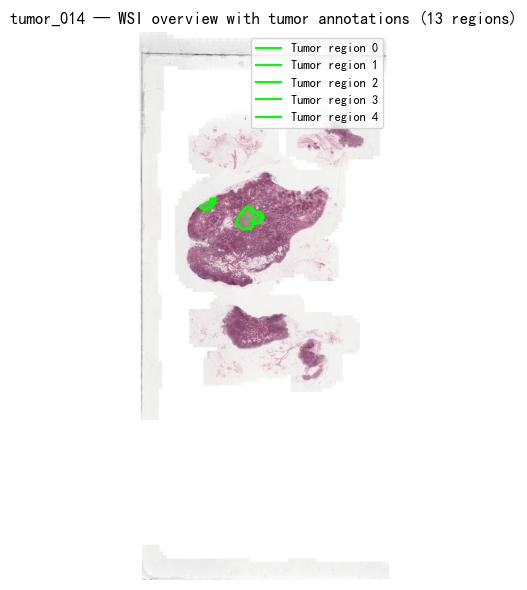

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(14, 6))
ax.imshow(thumbnail)

thumb_h, thumb_w = thumbnail.shape[:2]
scale_x = thumb_w / slide_dims[0]
scale_y = thumb_h / slide_dims[1]

for i, poly in enumerate(tumor_polygons):
    # Outer boundary of the polygon
    exterior = np.array(poly.exterior.coords)
    xs_scaled = exterior[:, 0] * scale_x
    ys_scaled = exterior[:, 1] * scale_y
    ax.plot(xs_scaled, ys_scaled, color='lime', linewidth=1.5,
            label=f'Tumor region {i}' if i < 5 else None)
    ax.fill(xs_scaled, ys_scaled, color='lime', alpha=0.15)

ax.legend(fontsize=9, loc='upper right')
ax.set_title(f"{SLIDE_ID} — WSI overview with tumor annotations "
             f"({len(tumor_polygons)} regions)", fontsize=12)
ax.axis('off')
plt.tight_layout()
plt.show()

## Figure 2: Tumor Regions on the Tile Grid

Reshape `tumor_labels` into a 2D grid, cluster separate tumor areas, and display each region with an adaptive crop.
Green = tumor tile, gray = normal tile, black = non-tissue.

Found 1 tumor cluster(s)


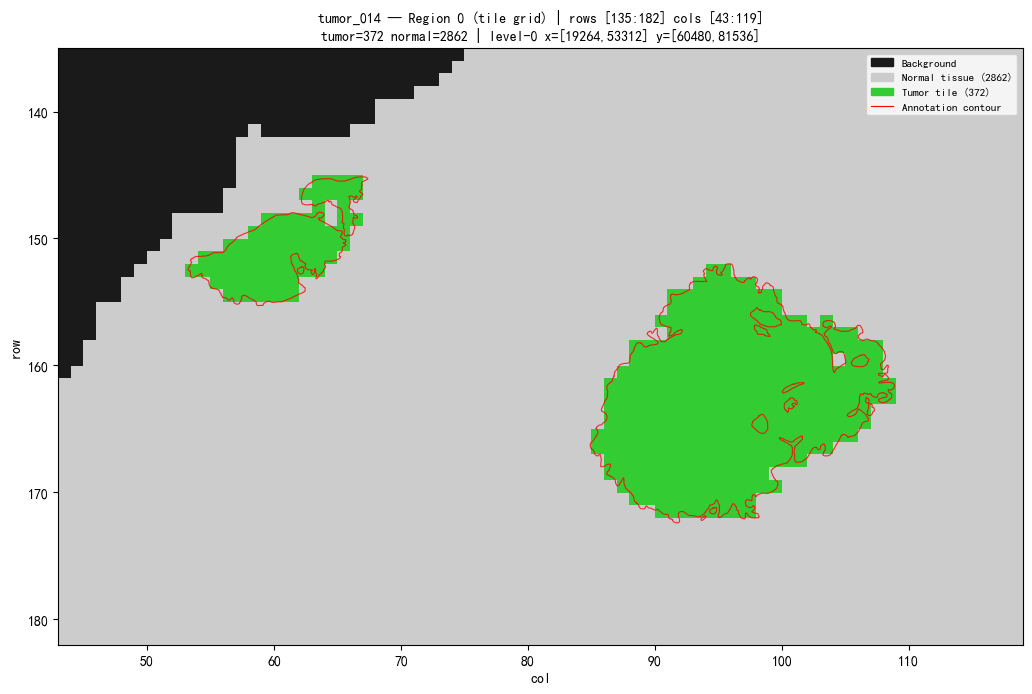

  Region 0: reading 47x76 tiles from 20x level ...


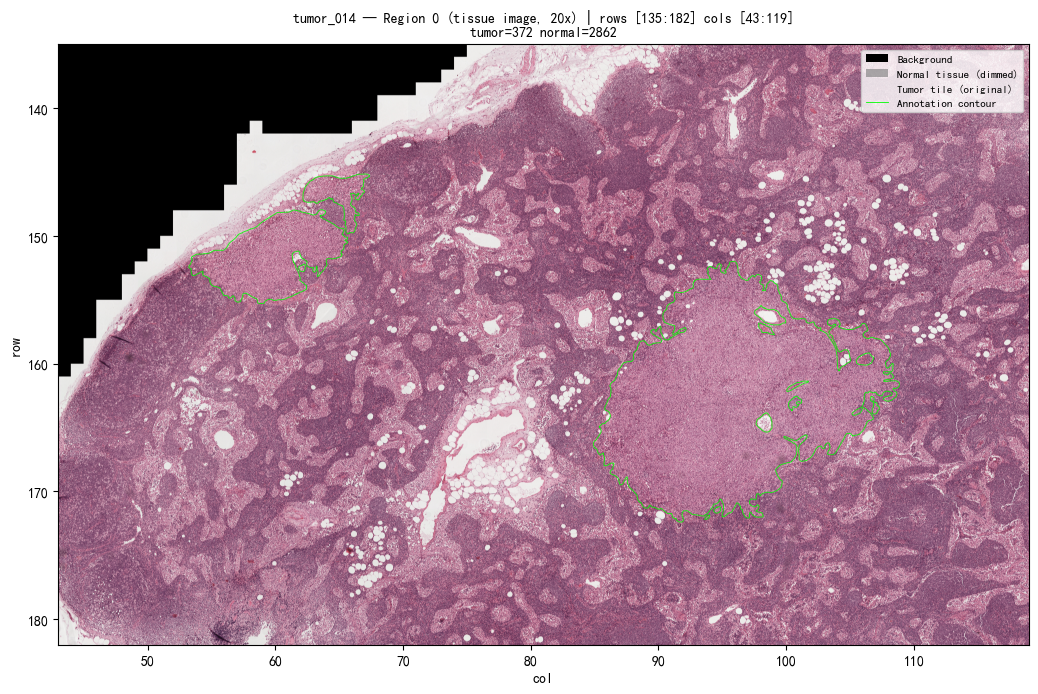

In [ ]:
def plot_tile_grid_regions(tumor_labels, tissue_mask, n_rows, n_cols,
                           tumor_polygons, coords, tile_size_l0,
                           context_pad, cluster_gap, slide_id,
                           slide_path, level_20x, tile_size):
    """Visualize tumor regions on the tile grid with adaptive crops.
    Each region is shown as a paired figure: left for the label grid, right for
    the underlying tissue image with annotation overlays.
    Only annotations intersecting the current region are drawn.
    """
    from shapely.geometry import box as shapely_box

    # Reshape flat labels into 2D grids.
    tumor_grid  = tumor_labels.reshape(n_rows, n_cols)
    tissue_grid = tissue_mask.reshape(n_rows, n_cols)

    # Three classes: 0=background, 1=normal tissue, 2=tumor tile
    grid_display = np.zeros((n_rows, n_cols), dtype=np.int32)
    grid_display[tissue_grid] = 1
    grid_display[tumor_grid]  = 2

    regions = cluster_tumor_regions(tumor_grid, context_pad, cluster_gap)
    if not regions:
        print("No tumor regions found in tile grid.")
        return

    print(f"Found {len(regions)} tumor cluster(s)")

    # Open the slide once so we can read the tissue patches for each region.
    slide = openslide.OpenSlide(str(slide_path))

    for idx, (rslice, cslice) in enumerate(regions):
        sub = grid_display[rslice, cslice]
        sub_rows, sub_cols = sub.shape
        n_tumor_sub = int((sub == 2).sum())
        n_normal_sub = int((sub == 1).sum())

        r_start, r_stop = rslice.start, rslice.stop
        c_start, c_stop = cslice.start, cslice.stop
        x_min = c_start * tile_size_l0
        x_max = c_stop * tile_size_l0
        y_min = r_start * tile_size_l0
        y_max = r_stop * tile_size_l0

        # Keep only annotations that intersect the current region.
        region_box = shapely_box(x_min, y_min, x_max, y_max)
        local_polys = [p for p in tumor_polygons if p.intersects(region_box)]

        # Keep the paired figures at roughly the same size.
        aspect = sub_cols / max(sub_rows, 1)
        fig_h = max(5, min(12, sub_rows * 0.15))
        fig_w = max(6, min(16, fig_h * aspect + 2))

        # Plot A: label grid
        fig, ax = plt.subplots(figsize=(fig_w, fig_h))
        cmap = ListedColormap(['#1a1a1a', '#cccccc', '#33cc33'])
        ax.imshow(sub, cmap=cmap, vmin=0, vmax=2, interpolation='nearest',
                  extent=[c_start, c_stop, r_stop, r_start])

        for poly in local_polys:
            exterior = np.array(poly.exterior.coords)
            cx = exterior[:, 0] / tile_size_l0
            cy = exterior[:, 1] / tile_size_l0
            ax.plot(cx, cy, color='red', linewidth=0.8, alpha=0.8)

        # Lock the axes to the current crop.
        ax.set_xlim(c_start, c_stop)
        ax.set_ylim(r_stop, r_start)

        legend_handles = [
            mpatches.Patch(color='#1a1a1a', label='Background'),
            mpatches.Patch(color='#cccccc', label=f'Normal tissue ({n_normal_sub})'),
            mpatches.Patch(color='#33cc33', label=f'Tumor tile ({n_tumor_sub})'),
            plt.Line2D([0], [0], color='red', linewidth=0.8,
                       label='Annotation contour'),
        ]
        ax.legend(handles=legend_handles, fontsize=8, loc='upper right')
        ax.set_xlabel("col")
        ax.set_ylabel("row")
        ax.set_title(
            f"{slide_id} — Region {idx} (tile grid) | "
            f"rows [{r_start}:{r_stop}] cols [{c_start}:{c_stop}]\n"
            f"tumor={n_tumor_sub} normal={n_normal_sub} | "
            f"level-0 x=[{x_min},{x_max}] y=[{y_min},{y_max}]",
            fontsize=10,
        )
        plt.tight_layout()
        plt.show()

        # Plot B: tissue image with overlay
        print(f"  Region {idx}: reading {sub_rows}x{sub_cols} tiles from 20x level ...")
        canvas = np.zeros((sub_rows * tile_size, sub_cols * tile_size, 3), dtype=np.uint8)

        for dr in range(sub_rows):
            for dc in range(sub_cols):
                r_abs = r_start + dr
                c_abs = c_start + dc
                flat_idx = r_abs * n_cols + c_abs
                x_l0 = int(coords[flat_idx, 0])
                y_l0 = int(coords[flat_idx, 1])
                tile_img = slide.read_region(
                    (x_l0, y_l0), level_20x, (tile_size, tile_size)
                ).convert('RGB')
                canvas[dr * tile_size:(dr + 1) * tile_size,
                       dc * tile_size:(dc + 1) * tile_size] = np.array(tile_img)

        # Build an overlay that hides background and dims normal tissue.
        overlay = canvas.copy().astype(np.float32)
        for dr in range(sub_rows):
            for dc in range(sub_cols):
                label_val = sub[dr, dc]
                y0 = dr * tile_size
                y1 = y0 + tile_size
                x0 = dc * tile_size
                x1 = x0 + tile_size
                if label_val == 0:
                    overlay[y0:y1, x0:x1] = 0
                elif label_val == 1:
                    overlay[y0:y1, x0:x1] = (
                        overlay[y0:y1, x0:x1] * 0.95 + 128 * 0.05
                    )

        composite = np.clip(overlay, 0, 255).astype(np.uint8)

        fig2, ax2 = plt.subplots(figsize=(fig_w, fig_h))
        ax2.imshow(composite,
                   extent=[c_start, c_stop, r_stop, r_start],
                   interpolation='bilinear')

        for poly in local_polys:
            exterior = np.array(poly.exterior.coords)
            cx = exterior[:, 0] / tile_size_l0
            cy = exterior[:, 1] / tile_size_l0
            ax2.plot(cx, cy, color='lime', linewidth=0.6, alpha=0.9)

        # Lock the axes to the current crop.
        ax2.set_xlim(c_start, c_stop)
        ax2.set_ylim(r_stop, r_start)

        legend_handles2 = [
            mpatches.Patch(facecolor='black', label='Background'),
            mpatches.Patch(facecolor='#808080', alpha=0.65, label='Normal tissue (dimmed)'),
            mpatches.Patch(facecolor='#ff6666', alpha=0.0, edgecolor='#ff6666',
                           label='Tumor tile (original)'),
            plt.Line2D([0], [0], color='lime', linewidth=0.6,
                       label='Annotation contour'),
        ]
        ax2.legend(handles=legend_handles2, fontsize=8, loc='upper right')
        ax2.set_xlabel("col")
        ax2.set_ylabel("row")
        ax2.set_title(
            f"{slide_id} — Region {idx} (tissue image, 20x) | "
            f"rows [{r_start}:{r_stop}] cols [{c_start}:{c_stop}]\n"
            f"tumor={n_tumor_sub} normal={n_normal_sub}",
            fontsize=10,
        )
        plt.tight_layout()
        plt.show()

    slide.close()


plot_tile_grid_regions(
    tumor_labels, tissue_mask, n_rows, n_cols,
    tumor_polygons, coords, tile_size_l0,
    CONTEXT_PAD, CLUSTER_GAP, SLIDE_ID,
    slide_path, level_20x, tile_size,
)

## Figure 3: Embedding Projection for Tumor vs Normal

Take all tissue-tile embeddings from the visualization regions, project them with t-SNE or UMAP, and color them by tumor or normal label.

All regions merged: 3234 tiles (tumor=372, normal=2862) from 1 region(s)
  Using UMAP (N=3234) ...


C:\Users\chenk\AppData\Roaming\Python\Python310\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


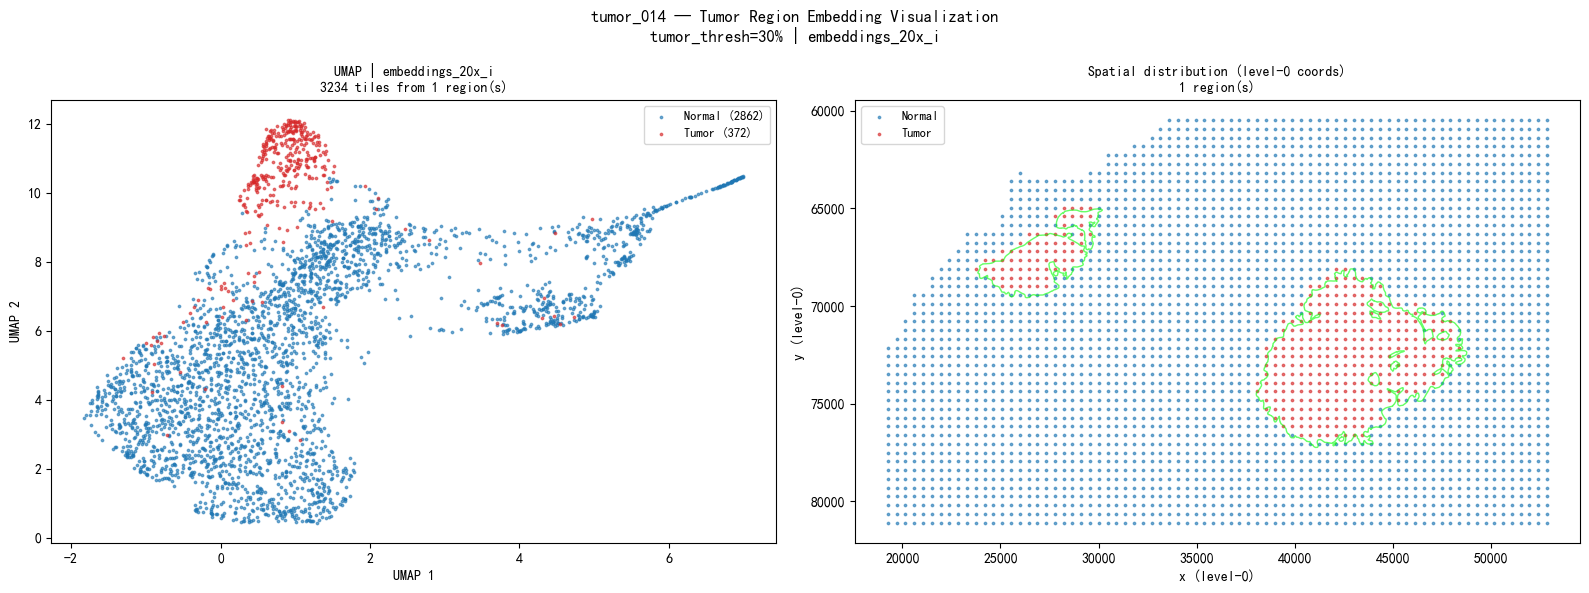

In [ ]:
def plot_embedding_by_region(tumor_labels, tissue_mask, embeddings, coords,
                             n_rows, n_cols, tumor_polygons, tile_size_l0,
                             context_pad, cluster_gap, slide_id, embedding_key):
    """Merge all tumor regions and project the tissue-tile embeddings in one plot."""
    from shapely.geometry import box as shapely_box

    tumor_grid  = tumor_labels.reshape(n_rows, n_cols)

    regions = cluster_tumor_regions(tumor_grid, context_pad, cluster_gap)
    if not regions:
        print("No tumor regions found.")
        return

    # Merge tile indices from all regions and remove duplicates.
    all_indices = set()
    for rslice, cslice in regions:
        row_idx = np.arange(rslice.start, rslice.stop)
        col_idx = np.arange(cslice.start, cslice.stop)
        mesh_r, mesh_c = np.meshgrid(row_idx, col_idx, indexing='ij')
        all_indices.update(mesh_r.ravel() * n_cols + mesh_c.ravel())

    all_indices = np.array(sorted(all_indices))

    # Keep tissue tiles only.
    is_tissue = tissue_mask[all_indices]
    tissue_indices = all_indices[is_tissue]

    if len(tissue_indices) < 10:
        print(f"Too few tissue tiles across all regions ({len(tissue_indices)}), skipping.")
        return

    embs   = embeddings[tissue_indices]
    labels = tumor_labels[tissue_indices]
    cds    = coords[tissue_indices]

    # Remove zero vectors so the projection is based on valid embeddings only.
    nz_mask = np.abs(embs).sum(axis=1) > 0
    embs   = embs[nz_mask]
    labels = labels[nz_mask]
    cds    = cds[nz_mask]
    n_tumor_v  = int(labels.sum())
    n_normal_v = len(labels) - n_tumor_v

    if len(embs) < 10:
        print(f"Too few non-zero embeddings ({len(embs)}), skipping.")
        return

    print(f"All regions merged: {len(embs)} tiles "
          f"(tumor={n_tumor_v}, normal={n_normal_v}) from {len(regions)} region(s)")

    # Run UMAP when available; otherwise fall back to t-SNE.
    try:
        import umap
        print(f"  Using UMAP (N={len(embs)}) ...")
        reducer = umap.UMAP(n_components=2, n_neighbors=min(30, len(embs)-1),
                            min_dist=0.1, random_state=42)
        coords2d = reducer.fit_transform(embs)
        method = 'UMAP'
    except ImportError:
        from sklearn.manifold import TSNE
        from sklearn.decomposition import PCA
        N_emb = len(embs)
        perp = min(40, N_emb // 4)
        if N_emb > 5000:
            print(f"  PCA 50 -> t-SNE (N={N_emb}) ...")
            embs_r = PCA(n_components=50, random_state=42).fit_transform(embs)
            method = 'PCA+t-SNE'
        else:
            print(f"  t-SNE (N={N_emb}, perp={perp}) ...")
            embs_r = embs
            method = 't-SNE'
        coords2d = TSNE(n_components=2, perplexity=max(5, perp),
                        random_state=42).fit_transform(embs_r)

    # One figure with two panels: projected features on the left, spatial layout on the right.
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    s = max(3, min(20, 10000 // len(embs)))
    axes[0].scatter(coords2d[~labels, 0], coords2d[~labels, 1],
                    c='tab:blue', s=s, alpha=0.6, label=f'Normal ({n_normal_v})')
    axes[0].scatter(coords2d[labels, 0], coords2d[labels, 1],
                    c='tab:red', s=s, alpha=0.6, label=f'Tumor ({n_tumor_v})')
    axes[0].legend(fontsize=9)
    axes[0].set_title(f"{method} | {embedding_key}\n"
                      f"{len(embs)} tiles from {len(regions)} region(s)", fontsize=10)
    axes[0].set_xlabel(f"{method} 1")
    axes[0].set_ylabel(f"{method} 2")

    # Right panel: spatial positions in level-0 coordinates.
    cols_v = cds[:, 0].astype(float)
    rows_v = cds[:, 1].astype(float)
    axes[1].scatter(cols_v[~labels], rows_v[~labels],
                    c='tab:blue', s=max(2, s), alpha=0.6, label='Normal')
    axes[1].scatter(cols_v[labels], rows_v[labels],
                    c='tab:red', s=max(2, s), alpha=0.6, label='Tumor')

    # Draw only annotation contours intersecting the merged regions.
    for rslice, cslice in regions:
        x_min = cslice.start * tile_size_l0
        x_max = cslice.stop * tile_size_l0
        y_min = rslice.start * tile_size_l0
        y_max = rslice.stop * tile_size_l0
        region_box = shapely_box(x_min, y_min, x_max, y_max)
        for poly in tumor_polygons:
            if poly.intersects(region_box):
                exterior = np.array(poly.exterior.coords)
                axes[1].plot(exterior[:, 0], exterior[:, 1],
                             color='lime', linewidth=1, alpha=0.6)

    axes[1].invert_yaxis()
    axes[1].legend(fontsize=9)
    axes[1].set_title(f"Spatial distribution (level-0 coords)\n"
                      f"{len(regions)} region(s)", fontsize=10)
    axes[1].set_xlabel("x (level-0)")
    axes[1].set_ylabel("y (level-0)")

    fig.suptitle(
        f"{slide_id} — Tumor Region Embedding Visualization\n"
        f"tumor_thresh={TUMOR_THRESH:.0%} | {embedding_key}",
        fontsize=12,
    )
    plt.tight_layout()
    plt.show()


plot_embedding_by_region(
    tumor_labels, tissue_mask, embeddings, coords,
    n_rows, n_cols, tumor_polygons, tile_size_l0,
    CONTEXT_PAD, CLUSTER_GAP, SLIDE_ID, EMBEDDING_KEY,
)

## Global Embedding Projection (Optional)

Project embeddings for all tissue tiles in the WSI and color them by tumor vs normal to inspect the global structure.

## Notes

Change the parameters at the top of the notebook to switch slides or adjust the visualization setup:

```python
SLIDE_ID      = "tumor_005"         # Switch to another slide
TUMOR_THRESH  = 0.10                # Lower threshold: more tiles become tumor
CONTEXT_PAD   = 15                  # Expand the displayed region
EMBEDDING_KEY = "embeddings_20x_i"  # Use ImageNet embeddings instead
```

# Write tumor and normal tile labels back into HDF5

New field:
`tumor_mask: (N,) bool`  # Precomputed label for whether a tile is tumor at the chosen area threshold

In [ ]:
# Batch-write the tumor_mask field into all tumor-slide HDF5 files.
# This cell reuses parse_annotations_xml and compute_tile_tumor_labels defined above.
# The tumor-area threshold is fixed here.

INJECT_THRESH    = 0.30
INJECT_OVERWRITE = True   # True: replace an existing tumor_mask; False: leave it untouched

h5_files = sorted(H5_DIR.glob("tumor_*.h5"))
xml_files_available = {p.stem for p in ANNOT_DIR.glob("tumor_*.xml")}

print(f"H5 files: {len(h5_files)}, XML annotations: {len(xml_files_available)}")
print(f"Tumor area threshold: {INJECT_THRESH}  |  overwrite: {INJECT_OVERWRITE}")
print("=" * 70)

n_done = 0
n_skip_no_xml = 0
n_skip_exists = 0
n_error = 0

for h5_file in h5_files:
    slide_id = h5_file.stem
    xml_file = ANNOT_DIR / f"{slide_id}.xml"

    # Skip slides that do not have a matching annotation XML.
    if slide_id not in xml_files_available:
        n_skip_no_xml += 1
        print(f"[SKIP] {slide_id}: no annotation XML")
        continue

    # Check whether tumor_mask is already present.
    with h5py.File(h5_file, 'r') as f:
        already_exists = 'tumor_mask' in f

    if already_exists:
        if not INJECT_OVERWRITE:
            n_skip_exists += 1
            print(f"[SKIP] {slide_id}: tumor_mask already exists")
            continue
        else:
            print(f"[OVERWRITE] {slide_id}: deleting existing tumor_mask ...")
            with h5py.File(h5_file, 'a') as f:
                del f['tumor_mask']

    try:
        # 1) Parse annotations
        polygons = parse_annotations_xml(xml_file)

        # 2) Read tile coordinates
        with h5py.File(h5_file, 'r') as f:
            coords_h5 = f['coords'][:]
            tile_sz = int(f.attrs['tile_size'])

        # Infer tile_size_l0 from adjacent x coordinates.
        xs_u = np.sort(np.unique(coords_h5[:, 0]))
        ts_l0 = int(xs_u[1] - xs_u[0]) if len(xs_u) > 1 else tile_sz

        # 3) Convert tumor ratios into a boolean mask
        print(f"[PROC] {slide_id}: {len(coords_h5)} tiles, "
              f"{len(polygons)} polygons, tile_l0={ts_l0} ...")
        ratios = compute_tile_tumor_labels(coords_h5, ts_l0, polygons)
        tmask = ratios >= INJECT_THRESH
        n_t = int(tmask.sum())

        # 4) Write the mask into HDF5
        with h5py.File(h5_file, 'a') as f:
            f.create_dataset('tumor_mask', data=tmask, dtype=bool,
                             compression='gzip', compression_opts=4)

        print(f"         -> tumor_mask written: {n_t}/{len(tmask)} "
              f"({n_t/len(tmask)*100:.1f}%) tumor tiles")
        n_done += 1

    except Exception as e:
        n_error += 1
        print(f"[ERROR] {slide_id}: {e}")

print("=" * 70)
print(f"Done. processed={n_done}, skip_exists={n_skip_exists}, "
      f"skip_no_xml={n_skip_no_xml}, errors={n_error}")

H5 files: 111, XML annotations: 111
Tumor area threshold: 0.3  |  overwrite: True
[OVERWRITE] tumor_001: deleting existing tumor_mask ...
[PROC] tumor_001: 107474 tiles, 2 polygons, tile_l0=448 ...
    bbox pre-filter: 224/107474 candidates
         -> tumor_mask written: 65/107474 (0.1%) tumor tiles
[OVERWRITE] tumor_002: deleting existing tumor_mask ...
[PROC] tumor_002: 106820 tiles, 1 polygons, tile_l0=448 ...
    bbox pre-filter: 24/106820 candidates
         -> tumor_mask written: 6/106820 (0.0%) tumor tiles
[OVERWRITE] tumor_003: deleting existing tumor_mask ...
[PROC] tumor_003: 107474 tiles, 14 polygons, tile_l0=448 ...
    bbox pre-filter: 289/107474 candidates
         -> tumor_mask written: 44/107474 (0.0%) tumor tiles
[OVERWRITE] tumor_004: deleting existing tumor_mask ...
[PROC] tumor_004: 107256 tiles, 8 polygons, tile_l0=448 ...
    bbox pre-filter: 304/107256 candidates
         -> tumor_mask written: 182/107256 (0.2%) tumor tiles
[OVERWRITE] tumor_005: deleting existi